# URL Model Training Walkthrough

**Audience**: 需要理解当前 URL 风险模型设计与训练过程的开发者、审计人员或论文作者。

**Prerequisites**: 熟悉 Python、scikit-learn、基础机器学习评估指标。

**Learning goals**

- 看懂当前线上 URL 模型是什么。
- 复现一套可控的 URL 训练与验证流程。
- 产出可直接用于论文或汇报的图表与表格。
- 理解为什么当前方案保留为字符级 TF-IDF + LogisticRegression。

## Outline

1. 检查数据集与标签分布。
2. 读取现在线上 `phishing_url.pkl`，确认真实管线。
3. 抽样训练集，对比 `LogisticRegression`、`SGDClassifier`、`MultinomialNB`。
4. 生成指标表、柱状图、ROC 曲线、混淆矩阵。
5. 提取高权重字符 n-gram，并生成词云图。
6. 总结当前方案的收益、代价和适用边界。

### Cell Guide 1: 环境与路径初始化

**目的**

- 导入后续训练、评估、绘图和词云所需的库。
- 固定随机种子，保证结果可复现。
- 定义训练集、模型产物和图片导出目录。

**执行后你应该看到**

- 训练集 CSV 路径
- 当前线上 URL 模型 `phishing_url.pkl` 路径
- 图表导出目录

**怎么解读**

这格如果失败，后面的所有训练和绘图都无法进行；它是 notebook 的统一状态初始化单元。

In [1]:
from __future__ import annotations

import csv
import random
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == "jupyter-notebook" else Path.cwd()
DATASET_PATH = PROJECT_ROOT / "ml" / "training" / "email_url" / "phishing_site_urls.csv"
ARTIFACT_PATH = PROJECT_ROOT / "ml" / "artifacts" / "phishing_url.pkl"
FIGURE_DIR = PROJECT_ROOT / "output" / "jupyter-notebook" / "url-model-figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
SAMPLE_PER_CLASS = 12_000

random.seed(SEED)
np.random.seed(SEED)
plt.style.use("default")


def show_table(rows, columns=None, limit=None):
    rows = list(rows)
    if limit is not None:
        rows = rows[:limit]
    if not rows:
        print("<empty>")
        return rows
    if columns is None:
        columns = list(rows[0].keys())
    widths = {}
    for col in columns:
        widths[col] = max(len(str(col)), max(len(str(row.get(col, ""))) for row in rows))
    header = " | ".join(str(col).ljust(widths[col]) for col in columns)
    sep = "-+-".join("-" * widths[col] for col in columns)
    print(header)
    print(sep)
    for row in rows:
        print(" | ".join(str(row.get(col, "")).ljust(widths[col]) for col in columns))
    return rows


def save_figure(name: str):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"saved -> {path}")
    return path


print(DATASET_PATH)
print(ARTIFACT_PATH)
print(FIGURE_DIR)

/Users/qwx/dev/code/PEA_Agent/ml/training/email_url/phishing_site_urls.csv
/Users/qwx/dev/code/PEA_Agent/ml/artifacts/phishing_url.pkl
/Users/qwx/dev/code/PEA_Agent/output/jupyter-notebook/url-model-figures


## 1. 数据集结构

这里使用仓库里保留的 URL 训练集。当前任务只关心两列：

- `URL`
- `Label`，其中 `bad` 表示恶意，`good` 表示正常

先检查类别分布和若干样本。

### Cell Guide 2: 数据集分布与样本预览

**目的**

- 读取 URL 数据集。
- 统计 `good / bad` 标签数量。
- 抽几条样本 URL 预览数据风格。

**执行后你应该看到**

- 一个标签分布表
- 一个样本预览表

**怎么解读**

如果 `good` 显著多于 `bad`，说明这是不平衡数据集。后续选择均衡抽样，是为了让教学实验更容易比较模型本身而不是类别比例。

In [2]:
with DATASET_PATH.open("r", encoding="utf-8", errors="ignore", newline="") as f:
    reader = csv.DictReader(f)
    rows = [row for row in reader]

label_counts = Counter((row.get("Label") or "").strip().lower() for row in rows)
label_rows = sorted(
    ({"label": key, "count": value} for key, value in label_counts.items()),
    key=lambda item: item["count"],
    reverse=True,
)
show_table(label_rows, columns=["label", "count"])

preview_rows = []
for row in rows[:5]:
    preview_rows.append(
        {
            "label": (row.get("Label") or "").strip().lower(),
            "url_preview": (row.get("URL") or "").strip()[:96],
        }
    )
print()
show_table(preview_rows, columns=["label", "url_preview"])


label | count 
------+-------
good  | 392924
bad   | 156422

label | url_preview                                                                                     
------+-------------------------------------------------------------------------------------------------
bad   | nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ff
bad   | www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home-customer&nav=1/loading.php               
bad   | serviciosbys.com/paypal.cgi.bin.get-into.herf.secure.dispatch35463256rzr321654641dsf654321874/hr
bad   | mail.printakid.com/www.online.americanexpress.com/index.html                                    
bad   | thewhiskeydregs.com/wp-content/themes/widescreen/includes/temp/promocoessmiles/?84784787824HDJND


[{'label': 'bad',
  'url_preview': 'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ff'},
 {'label': 'bad',
  'url_preview': 'www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home-customer&nav=1/loading.php'},
 {'label': 'bad',
  'url_preview': 'serviciosbys.com/paypal.cgi.bin.get-into.herf.secure.dispatch35463256rzr321654641dsf654321874/hr'},
 {'label': 'bad',
  'url_preview': 'mail.printakid.com/www.online.americanexpress.com/index.html'},
 {'label': 'bad',
  'url_preview': 'thewhiskeydregs.com/wp-content/themes/widescreen/includes/temp/promocoessmiles/?84784787824HDJND'}]

### Cell Guide 3: 标签分布柱状图

**目的**

- 把上一格的标签统计转换成可以直接用于论文的图。

**执行后你应该看到**

- 标签分布柱状图
- 同时导出 `dataset-label-distribution.png`

**怎么解读**

这张图适合放在“数据集描述”部分，用来解释训练集类别不均衡这一背景。

saved -> /Users/qwx/dev/code/PEA_Agent/output/jupyter-notebook/url-model-figures/dataset-label-distribution.png


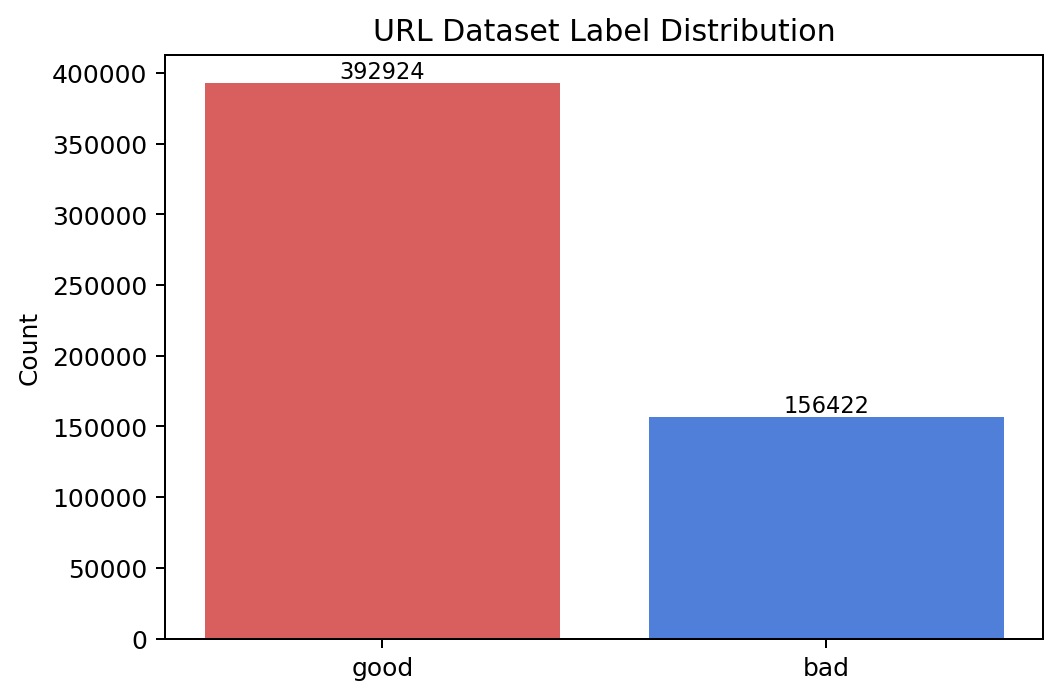

In [3]:
labels = [row["label"] for row in label_rows]
counts = [row["count"] for row in label_rows]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts, color=["#d95f5f", "#4f7fd8"])
ax.set_title("URL Dataset Label Distribution")
ax.set_ylabel("Count")
for bar, value in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value}", ha="center", va="bottom", fontsize=9)
figure_path = save_figure("dataset-label-distribution.png")
display(Image(filename=str(figure_path)))
plt.close(fig)

### 图表解读：数据集标签分布

- 这张图说明原始公开数据集存在明显类别不均衡。
- 因此后面的实验使用均衡抽样，目的是让模型对比更关注特征表达能力，而不是单纯受类别占比影响。
- 如果你写论文，建议在图注里明确说明“后续实验采用 balanced sample”。

这个数据集明显不平衡，`good` 多于 `bad`。为了让 notebook 可重复且运行时间可控，后续会做**按类均衡抽样**，而不是整表全量训练。

## 2. 现在线上模型到底是什么

不要靠旧文档猜，直接读取当前 artifact。

### Cell Guide 4: 读取现网模型 artifact

**目的**

- 直接加载当前线上在用的 URL 模型，而不是依赖旧文档描述。

**执行后你应该看到**

- 一个 `Pipeline` 对象

**怎么解读**

这一步是“证据化说明当前模型”的关键。论文或汇报里引用模型结构时，应以这里加载出来的真实产物为准。

In [4]:
artifact = joblib.load(ARTIFACT_PATH)
artifact

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(analyzer='char_wb', max_features=250000,
                                 min_df=2, ngram_range=(3, 5),
                                 sublinear_tf=True)),
                ('clf', LogisticRegression(C=3.0, max_iter=1500))])

### Cell Guide 5: 输出模型结构参数表

**目的**

- 展示向量器和分类器的关键配置项。

**执行后你应该看到**

- `analyzer`、`ngram_range`、`max_features`、`C`、`max_iter` 等参数表

**怎么解读**

这张表适合放到“模型配置”小节，说明当前方案是字符级 TF-IDF 配合 LogisticRegression，而不是更重的深度模型。

In [5]:
vectorizer = artifact.named_steps["vectorizer"]
classifier = artifact.named_steps["clf"]
artifact_info = [
    {"component": "vectorizer", "type": type(vectorizer).__name__},
    {"component": "classifier", "type": type(classifier).__name__},
    {"component": "analyzer", "type": getattr(vectorizer, "analyzer", "<n/a>")},
    {"component": "ngram_range", "type": str(getattr(vectorizer, "ngram_range", "<n/a>"))},
    {"component": "max_features", "type": str(getattr(vectorizer, "max_features", "<n/a>"))},
    {"component": "min_df", "type": str(getattr(vectorizer, "min_df", "<n/a>"))},
    {"component": "sublinear_tf", "type": str(getattr(vectorizer, "sublinear_tf", "<n/a>"))},
    {"component": "classifier_C", "type": str(getattr(classifier, "C", "<n/a>"))},
    {"component": "classifier_max_iter", "type": str(getattr(classifier, "max_iter", "<n/a>"))},
]
show_table(artifact_info, columns=["component", "type"])


component           | type              
--------------------+-------------------
vectorizer          | TfidfVectorizer   
classifier          | LogisticRegression
analyzer            | char_wb           
ngram_range         | (3, 5)            
max_features        | 250000            
min_df              | 2                 
sublinear_tf        | True              
classifier_C        | 3.0               
classifier_max_iter | 1500              


[{'component': 'vectorizer', 'type': 'TfidfVectorizer'},
 {'component': 'classifier', 'type': 'LogisticRegression'},
 {'component': 'analyzer', 'type': 'char_wb'},
 {'component': 'ngram_range', 'type': '(3, 5)'},
 {'component': 'max_features', 'type': '250000'},
 {'component': 'min_df', 'type': '2'},
 {'component': 'sublinear_tf', 'type': 'True'},
 {'component': 'classifier_C', 'type': '3.0'},
 {'component': 'classifier_max_iter', 'type': '1500'}]

### 为什么当前方案是“字符级 TF-IDF + LogisticRegression”

这套组合适合 URL 的原因主要有四点：

1. **字符级 n-gram** 能看到 `login`, `secure`, `.php`, `/verify/`, `@`, `%` 这类局部模式，适合被混淆和切碎的 URL。
2. **TF-IDF** 会降低过于常见片段的权重，避免所有 `.com`、`http` 都被放大。
3. **LogisticRegression** 在高维稀疏特征上稳定、可解释、推理快。
4. 产物轻量，便于和当前后端同步加载。

下面用一个抽样实验，看看它和其他轻量模型相比表现如何。

### Cell Guide 6: 定义训练、抽样和评估函数

**目的**

- 封装后面会复用的训练辅助函数。
- 统一模型比较方式，避免每个模型用不同指标口径。

**执行后你应该看到**

- 没有显式输出，这一格主要是定义函数

**怎么解读**

这里把实验流程固定下来：均衡抽样、固定随机种子、统一 `precision / recall / f1 / auc / ROC / confusion matrix`。这样后续模型比较才公平。

In [6]:
def load_rows(path: Path):
    pairs = []
    with path.open("r", encoding="utf-8", errors="ignore", newline="") as f:
        for row in csv.DictReader(f):
            url = (row.get("URL") or "").strip().strip("'").strip('"')
            label = (row.get("Label") or "").strip().lower()
            if url and label in {"bad", "good"}:
                pairs.append((url, label))
    return pairs


def balanced_sample(pairs, per_class: int, seed: int = 42):
    rng = random.Random(seed)
    by_class = {"bad": [], "good": []}
    for url, label in pairs:
        by_class[label].append(url)
    size = min(per_class, len(by_class["bad"]), len(by_class["good"]))
    sample = [(u, "bad") for u in rng.sample(by_class["bad"], size)]
    sample += [(u, "good") for u in rng.sample(by_class["good"], size)]
    rng.shuffle(sample)
    return sample


def build_models():
    shared_vectorizer = dict(
        analyzer="char_wb",
        ngram_range=(3, 5),
        lowercase=True,
        min_df=2,
        max_features=250_000,
        sublinear_tf=True,
    )
    return {
        "logreg_current_style": Pipeline([
            ("vectorizer", TfidfVectorizer(**shared_vectorizer)),
            ("clf", LogisticRegression(max_iter=1500, C=3.0)),
        ]),
        "sgd_log_loss": Pipeline([
            ("vectorizer", TfidfVectorizer(**shared_vectorizer)),
            ("clf", SGDClassifier(loss="log_loss", max_iter=1500, random_state=SEED)),
        ]),
        "multinomial_nb": Pipeline([
            ("vectorizer", TfidfVectorizer(**shared_vectorizer)),
            ("clf", MultinomialNB(alpha=0.3)),
        ]),
    }


def evaluate_model(model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    positive_index = list(model.classes_).index("bad")
    probs = model.predict_proba(x_test)[:, positive_index]
    preds = ["bad" if p >= 0.5 else "good" for p in probs]
    y_true = np.array([1 if item == "bad" else 0 for item in y_test])
    y_pred = np.array([1 if item == "bad" else 0 for item in preds])
    fpr, tpr, thresholds = roc_curve(y_true, probs)
    return {
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall": round(recall_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred), 4),
        "auc": round(roc_auc_score(y_true, probs), 4),
        "y_true": y_true,
        "y_pred": y_pred,
        "fpr_curve": fpr,
        "tpr_curve": tpr,
        "thresholds": thresholds,
    }


## 3. 轻量模型对比

为了快速复现，我们取每类 `12,000` 条 URL 做均衡抽样，再做一次固定随机种子的训练/测试切分。

### Cell Guide 7: 训练三种轻量模型并输出指标表

**目的**

- 在同一份均衡抽样数据上比较三种候选：
  - `LogisticRegression`
  - `SGDClassifier`
  - `MultinomialNB`

**执行后你应该看到**

- 一张指标表，至少包含 `precision / recall / f1 / auc`

**怎么解读**

这是核心对比表。若一个模型在 `F1` 和 `AUC` 上都更稳，同时部署成本更低，那它就是更合理的线上候选。

In [7]:
pairs = load_rows(DATASET_PATH)
sampled = balanced_sample(pairs, SAMPLE_PER_CLASS, seed=SEED)
X = [url for url, _ in sampled]
y = [label for _, label in sampled]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

results = []
curves = {}
matrices = {}
models = build_models()
for name, model in models.items():
    metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
    curves[name] = metrics
    matrices[name] = confusion_matrix(metrics["y_true"], metrics["y_pred"])
    results.append({
        "model": name,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "auc": metrics["auc"],
    })

results = sorted(results, key=lambda item: (item["f1"], item["auc"]), reverse=True)
show_table(results, columns=["model", "precision", "recall", "f1", "auc"])


model                | precision | recall | f1     | auc   
---------------------+-----------+--------+--------+-------
logreg_current_style | 0.9623    | 0.925  | 0.9433 | 0.9871
multinomial_nb       | 0.9662    | 0.9046 | 0.9344 | 0.9874
sgd_log_loss         | 0.951     | 0.9054 | 0.9276 | 0.9802


[{'model': 'logreg_current_style',
  'precision': 0.9623,
  'recall': 0.925,
  'f1': 0.9433,
  'auc': 0.9871},
 {'model': 'multinomial_nb',
  'precision': 0.9662,
  'recall': 0.9046,
  'f1': 0.9344,
  'auc': 0.9874},
 {'model': 'sgd_log_loss',
  'precision': 0.951,
  'recall': 0.9054,
  'f1': 0.9276,
  'auc': 0.9802}]

### Cell Guide 8: 指标柱状图

**目的**

- 把表格里的核心指标可视化，便于论文和汇报直接引用。

**执行后你应该看到**

- 模型指标柱状图
- 导出 `model-metric-comparison.png`

**怎么解读**

如果某个模型在多个指标上都不占优，通常不值得为了“更复杂”而上线。

saved -> /Users/qwx/dev/code/PEA_Agent/output/jupyter-notebook/url-model-figures/model-metric-comparison.png


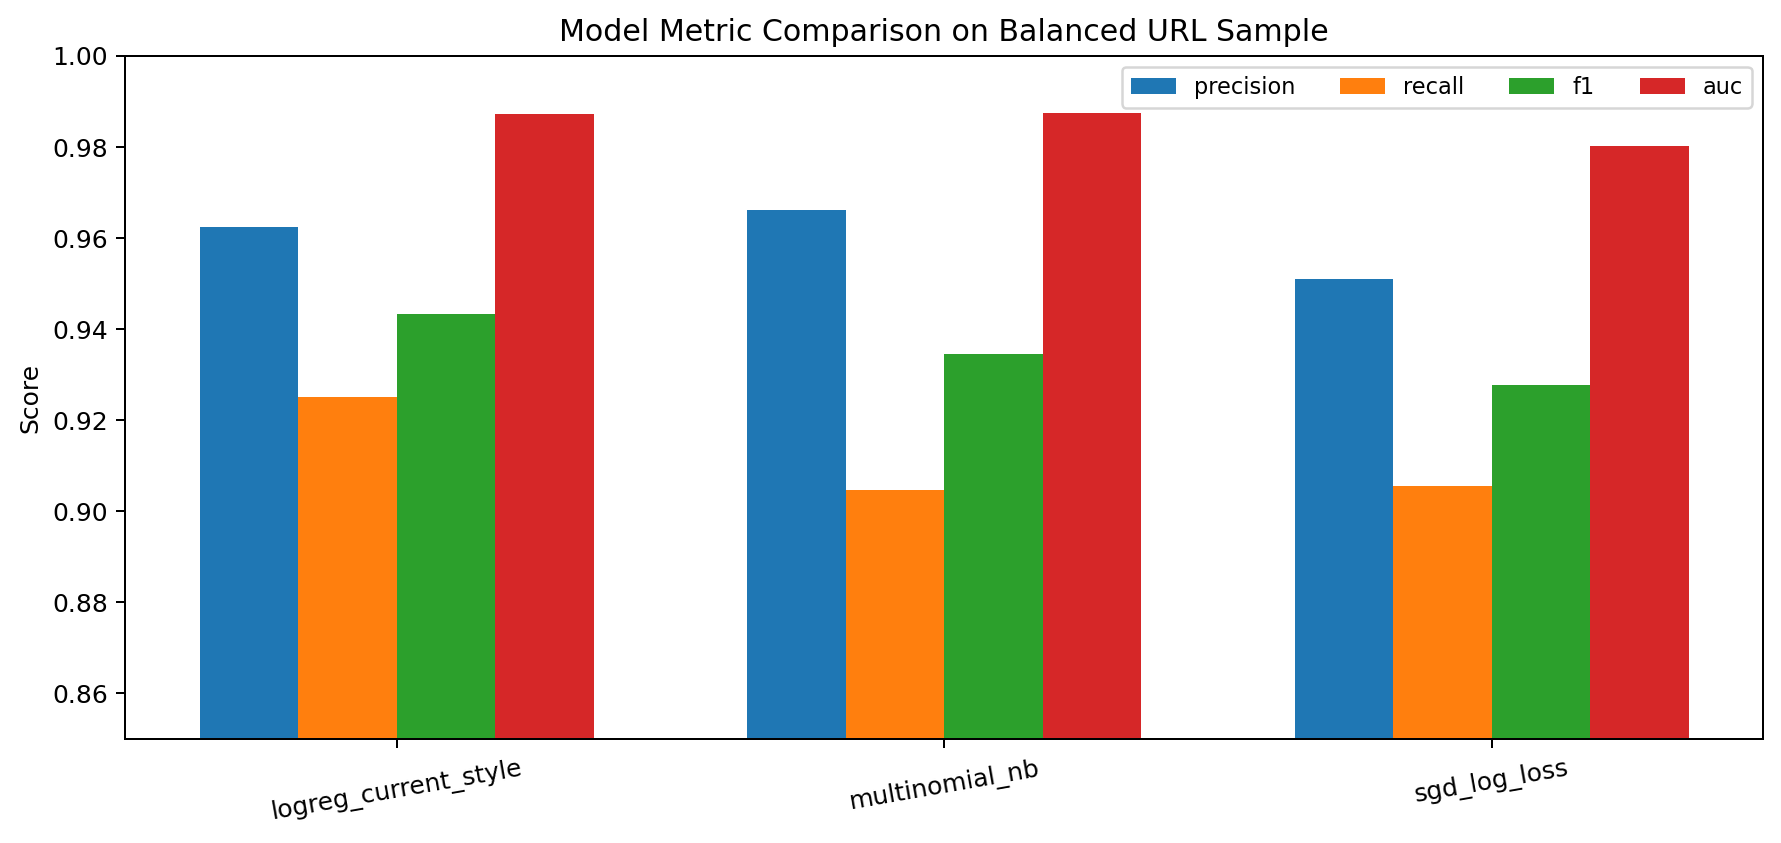

In [8]:
metrics_names = ["precision", "recall", "f1", "auc"]
model_names = [row["model"] for row in results]
x = np.arange(len(model_names))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 4.8))
for idx, metric_name in enumerate(metrics_names):
    values = [row[metric_name] for row in results]
    ax.bar(x + idx * width, values, width=width, label=metric_name)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=10)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("Score")
ax.set_title("Model Metric Comparison on Balanced URL Sample")
ax.legend(ncols=4, fontsize=9)
figure_path = save_figure("model-metric-comparison.png")
display(Image(filename=str(figure_path)))
plt.close(fig)

### 图表解读：模型指标对比

- 这张图适合支撑“为什么选择当前方案”的核心论点。
- 重点看 `F1` 和 `AUC`：前者反映精度与召回平衡，后者反映整体排序能力。
- 如果一个模型只是某一项略好，但整体更不稳定，通常不值得替换当前线上方案。

### Cell Guide 9: ROC 曲线

**目的**

- 展示不同模型在不同阈值下的整体区分能力。

**执行后你应该看到**

- 三条 ROC 曲线
- 导出 `roc-curves.png`

**怎么解读**

ROC 更适合说明模型整体能力，而不只是一组阈值下的单点指标。论文里通常会把它和 AUC 一起展示。

saved -> /Users/qwx/dev/code/PEA_Agent/output/jupyter-notebook/url-model-figures/roc-curves.png


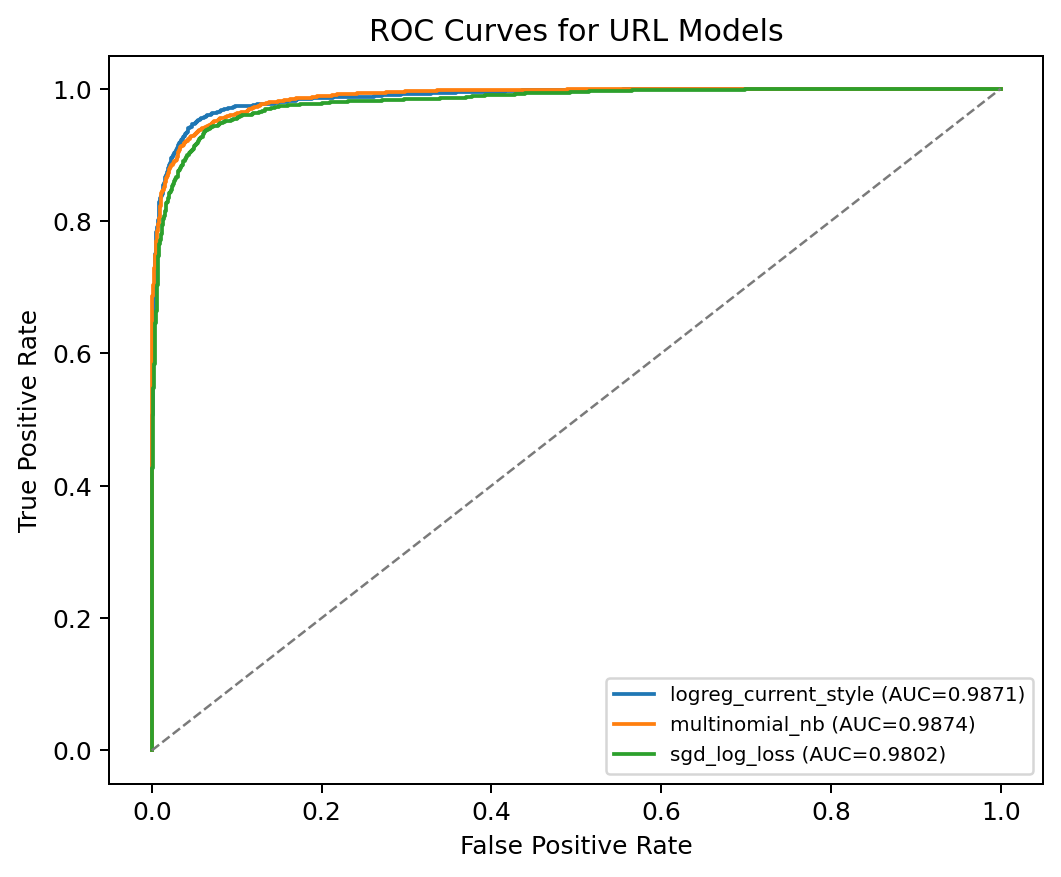

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
for row in results:
    curve = curves[row["model"]]
    ax.plot(curve["fpr_curve"], curve["tpr_curve"], label=f"{row['model']} (AUC={row['auc']:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="#7a7a7a", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves for URL Models")
ax.legend(fontsize=8)
figure_path = save_figure("roc-curves.png")
display(Image(filename=str(figure_path)))
plt.close(fig)

### 图表解读：ROC 曲线

- ROC 曲线越靠近左上角，说明模型整体区分能力越强。
- 这张图适合说明：即使阈值改变，当前方案整体仍然保持较强的可分性。
- 它通常和 AUC 一起引用，作为表格指标之外的补充证据。

### Cell Guide 10: 最优模型混淆矩阵

**目的**

- 展示当前最佳模型在测试集上的 TP / FP / TN / FN 结构。

**执行后你应该看到**

- 最优模型混淆矩阵
- 导出 `best-model-confusion-matrix.png`

**怎么解读**

这张图适合放在“误报/漏报分析”部分，帮助解释模型主要在哪一类样本上出错。

saved -> /Users/qwx/dev/code/PEA_Agent/output/jupyter-notebook/url-model-figures/best-model-confusion-matrix.png


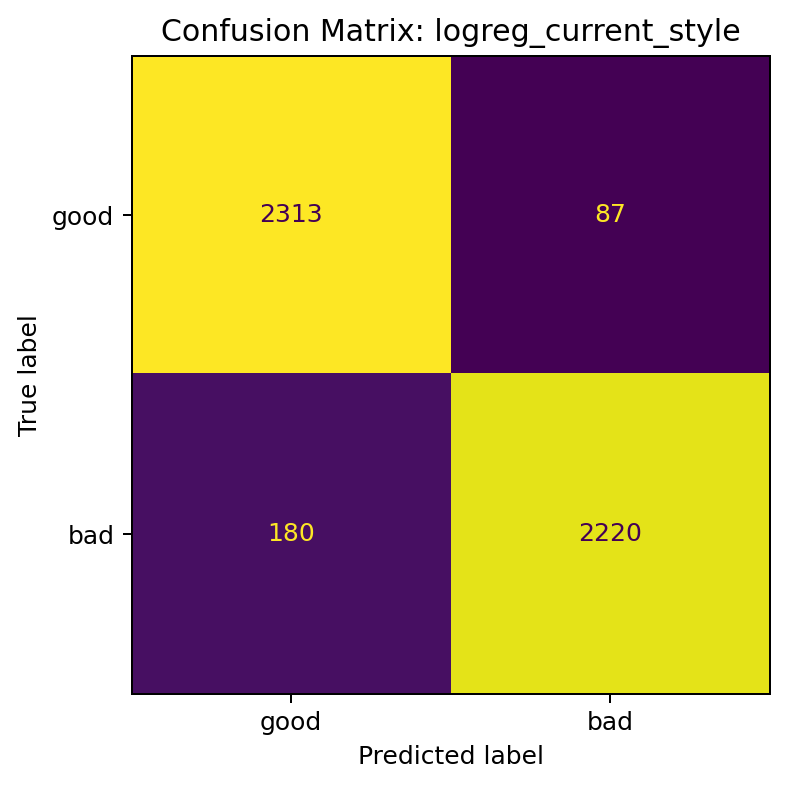

In [10]:
best_model_name = results[0]["model"]
best_matrix = matrices[best_model_name]
fig, ax = plt.subplots(figsize=(5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=best_matrix, display_labels=["good", "bad"])
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix: {best_model_name}")
figure_path = save_figure("best-model-confusion-matrix.png")
display(Image(filename=str(figure_path)))
plt.close(fig)

### 图表解读：混淆矩阵

- 混淆矩阵是论文里解释误报和漏报最直接的图。
- 如果 FP 偏高，说明正常 URL 容易被打成恶意；如果 FN 偏高，说明恶意 URL 容易漏检。
- 它能帮助把“模型表现”进一步落到安全风险语境里。

### 一次参考运行结果

在当前仓库数据上，用上面的抽样方式跑过一次，结果是：

| model | precision | recall | f1 | auc |
|---|---:|---:|---:|---:|
| logreg_current_style | 0.9623 | 0.9250 | 0.9433 | 0.9871 |
| multinomial_nb | 0.9662 | 0.9046 | 0.9344 | 0.9874 |
| sgd_log_loss | 0.9510 | 0.9054 | 0.9276 | 0.9802 |

这不是“全量最终 benchmark”，但足够说明当前方案在 `F1 / AUC / 稳定性` 上是合理的折中。

## 4. 看看 LogisticRegression 在关注什么

字符级模型不会给你“单词级语义”，但它能明确放大局部模式。下面取权重较高的一些 n-gram，并生成词云。

### Cell Guide 11: 提取高权重字符 n-gram

**目的**

- 从 LogisticRegression 权重里抽取最有代表性的恶意侧和正常侧字符 n-gram。
- 注意二分类 LogisticRegression 的 `coef_[0]` 对应 `classes_[1]`，所以必须先确认类别顺序再解释正负方向。

**执行后你应该看到**

- 恶意侧 n-gram 表
- 正常侧 n-gram 表

**怎么解读**

如果 `classes_ = ['bad', 'good']`，那么：

- **负权重** 更偏向 `bad`
- **正权重** 更偏向 `good`

这一步是后续条形图和词云的前置条件，方向标错了，整段解释都会反。

In [11]:
logreg_model = models["logreg_current_style"]
vectorizer = logreg_model.named_steps["vectorizer"]
classifier = logreg_model.named_steps["clf"]
feature_names = vectorizer.get_feature_names_out()
coefficients = classifier.coef_[0]
class_order = list(classifier.classes_)
positive_class = class_order[1]
negative_class = class_order[0]

# In sklearn binary logistic regression, coef_[0] is for classes_[1].
# Positive weights push toward the positive_class, negative weights push toward the negative_class.
top_positive = [
    {"ngram": feature_names[idx], "weight": round(float(coefficients[idx]), 6)}
    for idx in coefficients.argsort()[-20:][::-1]
]
top_negative = [
    {"ngram": feature_names[idx], "weight": round(float(coefficients[idx]), 6)}
    for idx in coefficients.argsort()[:20]
]

if positive_class == "bad":
    top_bad = top_positive
    top_good = top_negative
else:
    top_bad = top_negative
    top_good = top_positive

print(f"classes_: {class_order}")
print(f"malicious side inferred from: {'negative weights' if positive_class != 'bad' else 'positive weights'}")
print()
print("Top bad-side ngrams")
show_table(top_bad, columns=["ngram", "weight"], limit=15)
print()
print("Top good-side ngrams")
show_table(top_good, columns=["ngram", "weight"], limit=15)

classes_: ['bad', 'good']
malicious side inferred from: negative weights

Top bad-side ngrams
ngram | weight   
------+----------
.php  | -4.442059
php   | -4.363515
hp    | -4.35429 
.com. | -3.483161
php   | -3.474525
login | -3.448148
ogin  | -3.448148
om.   | -3.439297
ogi   | -3.399039
logi  | -3.358144
com.  | -3.318065
gin   | -3.21321 
/wp   | -3.180455
.php  | -3.158689
.ph   | -3.053955

Top good-side ngrams
ngram | weight  
------+---------
com/  | 4.808476
om/   | 4.78985 
m/    | 4.374488
.com/ | 4.16978 
com/  | 4.068973
om/   | 4.068785
htm   | 3.794225
.edu/ | 3.789651
edu/  | 3.733848
du/   | 3.729365
.asp  | 3.487478
200   | 3.409704
.htm  | 3.262055
.edu  | 3.257467
and   | 3.235239


[{'ngram': 'com/ ', 'weight': 4.808476},
 {'ngram': 'om/ ', 'weight': 4.78985},
 {'ngram': 'm/ ', 'weight': 4.374488},
 {'ngram': '.com/', 'weight': 4.16978},
 {'ngram': 'com/', 'weight': 4.068973},
 {'ngram': 'om/', 'weight': 4.068785},
 {'ngram': 'htm', 'weight': 3.794225},
 {'ngram': '.edu/', 'weight': 3.789651},
 {'ngram': 'edu/', 'weight': 3.733848},
 {'ngram': 'du/', 'weight': 3.729365},
 {'ngram': '.asp', 'weight': 3.487478},
 {'ngram': '200', 'weight': 3.409704},
 {'ngram': '.htm', 'weight': 3.262055},
 {'ngram': '.edu', 'weight': 3.257467},
 {'ngram': 'and', 'weight': 3.235239}]

### Cell Guide 12: 高权重特征条形图

**目的**

- 用更适合论文展示的方式，直接比较恶意侧和正常侧最强的字符 n-gram。

**执行后你应该看到**

- 左侧：恶意 URL 高权重 n-gram 条形图
- 右侧：正常 URL 高权重 n-gram 条形图
- 导出 `feature-weight-bar-charts.png`

**怎么解读**

条形图比词云更适合写论文，因为它保留了方向和相对强度：

- 条越长，说明对应 n-gram 对该类的推动越强
- 左右两侧可以直接比较“哪类模式更偏恶意，哪类模式更偏正常”

saved -> /Users/qwx/dev/code/PEA_Agent/output/jupyter-notebook/url-model-figures/feature-weight-bar-charts.png


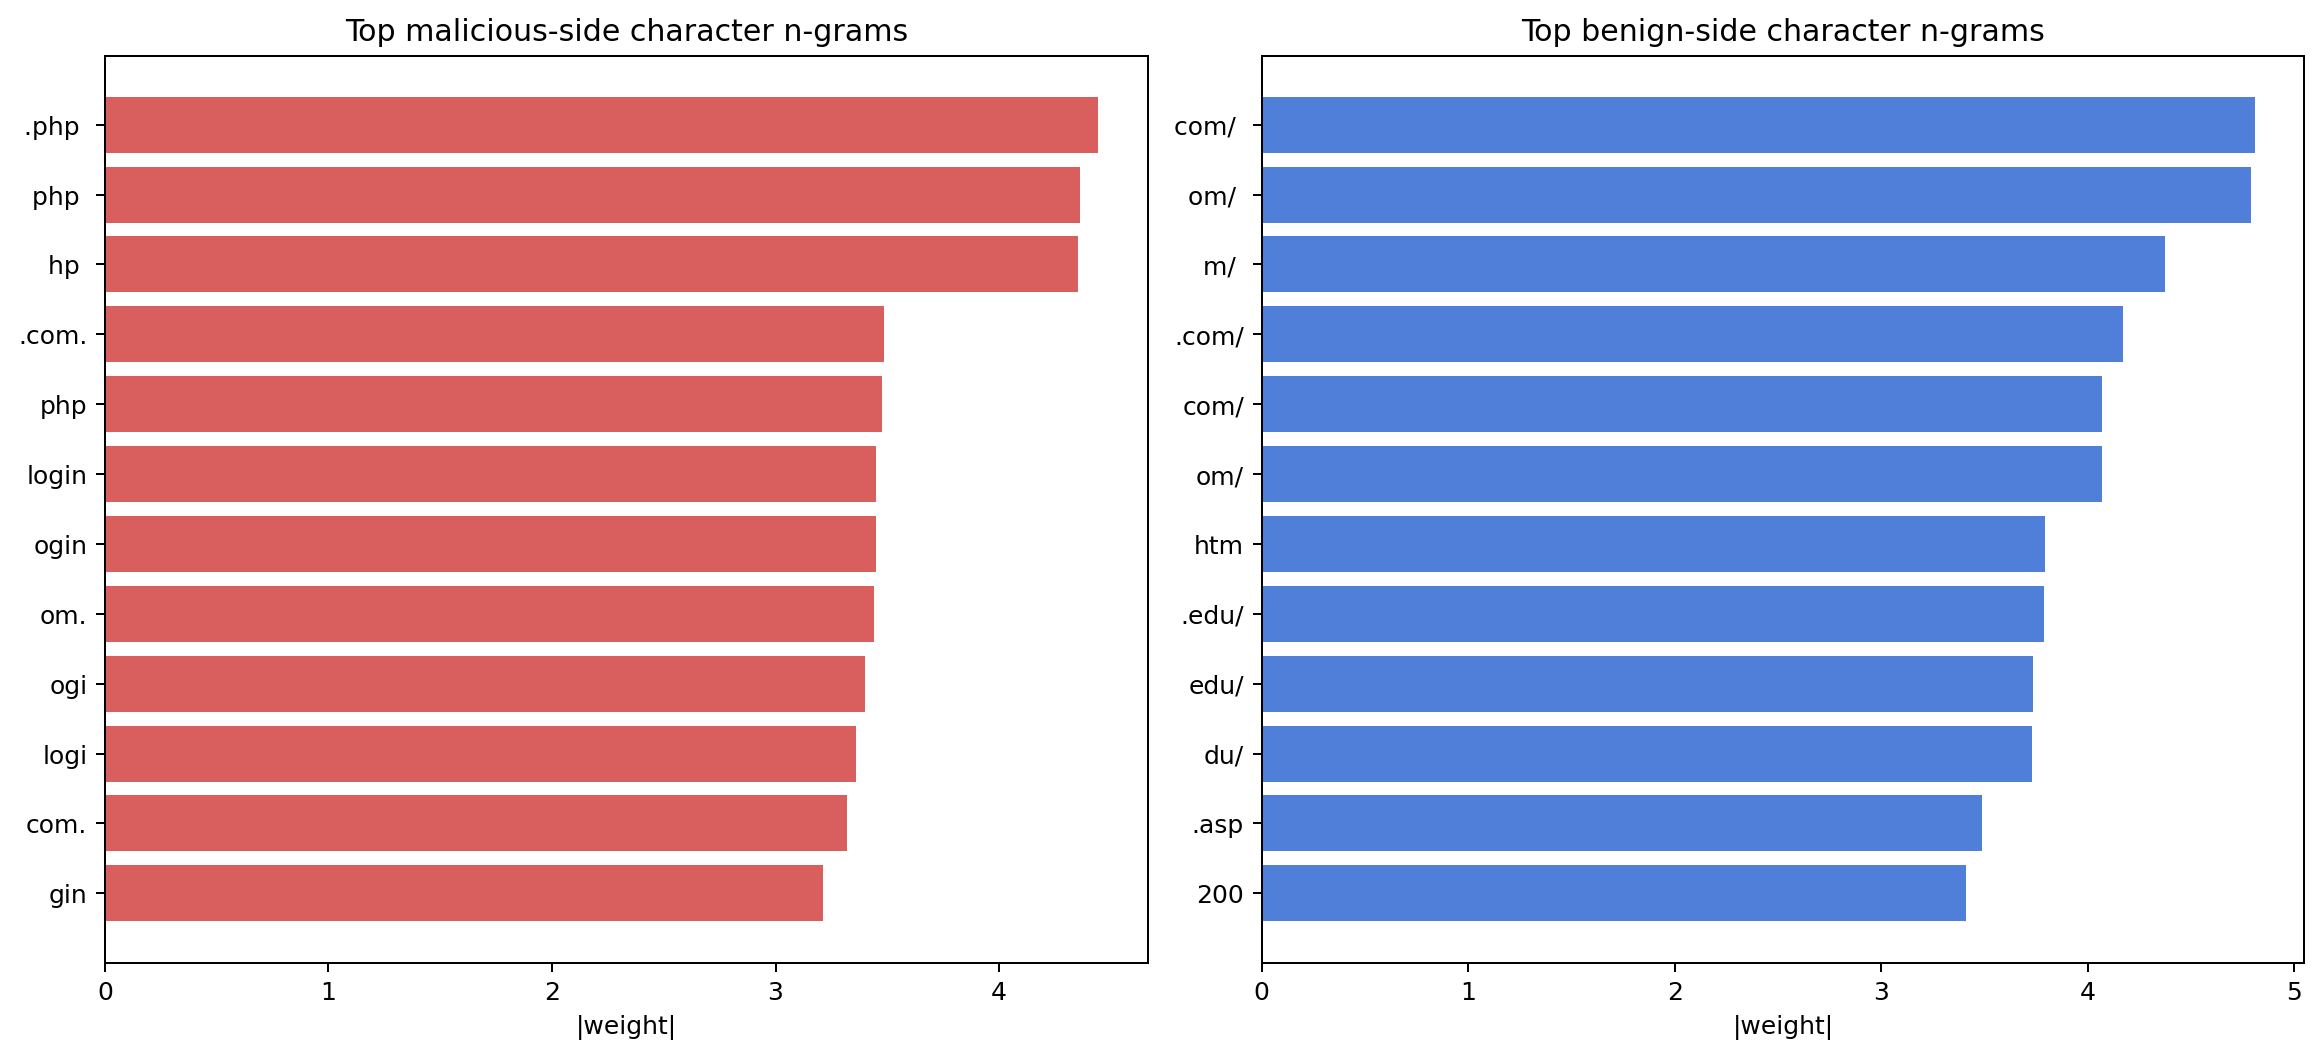

In [12]:
top_bad_plot = list(reversed(top_bad[:12]))
top_good_plot = list(reversed(top_good[:12]))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh([row["ngram"] for row in top_bad_plot], [abs(row["weight"]) for row in top_bad_plot], color="#d95f5f")
axes[0].set_title("Top malicious-side character n-grams")
axes[0].set_xlabel("|weight|")

axes[1].barh([row["ngram"] for row in top_good_plot], [abs(row["weight"]) for row in top_good_plot], color="#4f7fd8")
axes[1].set_title("Top benign-side character n-grams")
axes[1].set_xlabel("|weight|")

figure_path = save_figure("feature-weight-bar-charts.png")
display(Image(filename=str(figure_path)))
plt.close(fig)

### 图表解读：高权重特征条形图

- 这张图是这一部分最适合论文正文使用的主图。
- 它比词云更严谨，因为它保留了**方向**和**强度**。
- 如果某些片段只在恶意侧显著靠前，说明模型确实在利用 URL 的局部结构模式，而不是纯随机噪声。
- 如果两侧都出现大量相同片段，说明特征区分度不够，需要重新考虑 `ngram_range` 或引入词法特征。

### Cell Guide 13: 词云图（辅助图）

**目的**

- 把高权重字符 n-gram 转成更直观的视觉图，作为展示型辅助材料。

**执行后你应该看到**

- 恶意侧词云
- 正常侧词云
- 导出 `ngram-wordclouds.png`

**怎么解读**

词云只适合做补充图，不适合作为主要证据图。原因是：

- 它会弱化精确权重差异
- 对字符级 n-gram 的可读性本来就有限
- 更适合放在答辩或汇报里做直观展示

saved -> /Users/qwx/dev/code/PEA_Agent/output/jupyter-notebook/url-model-figures/ngram-wordclouds.png


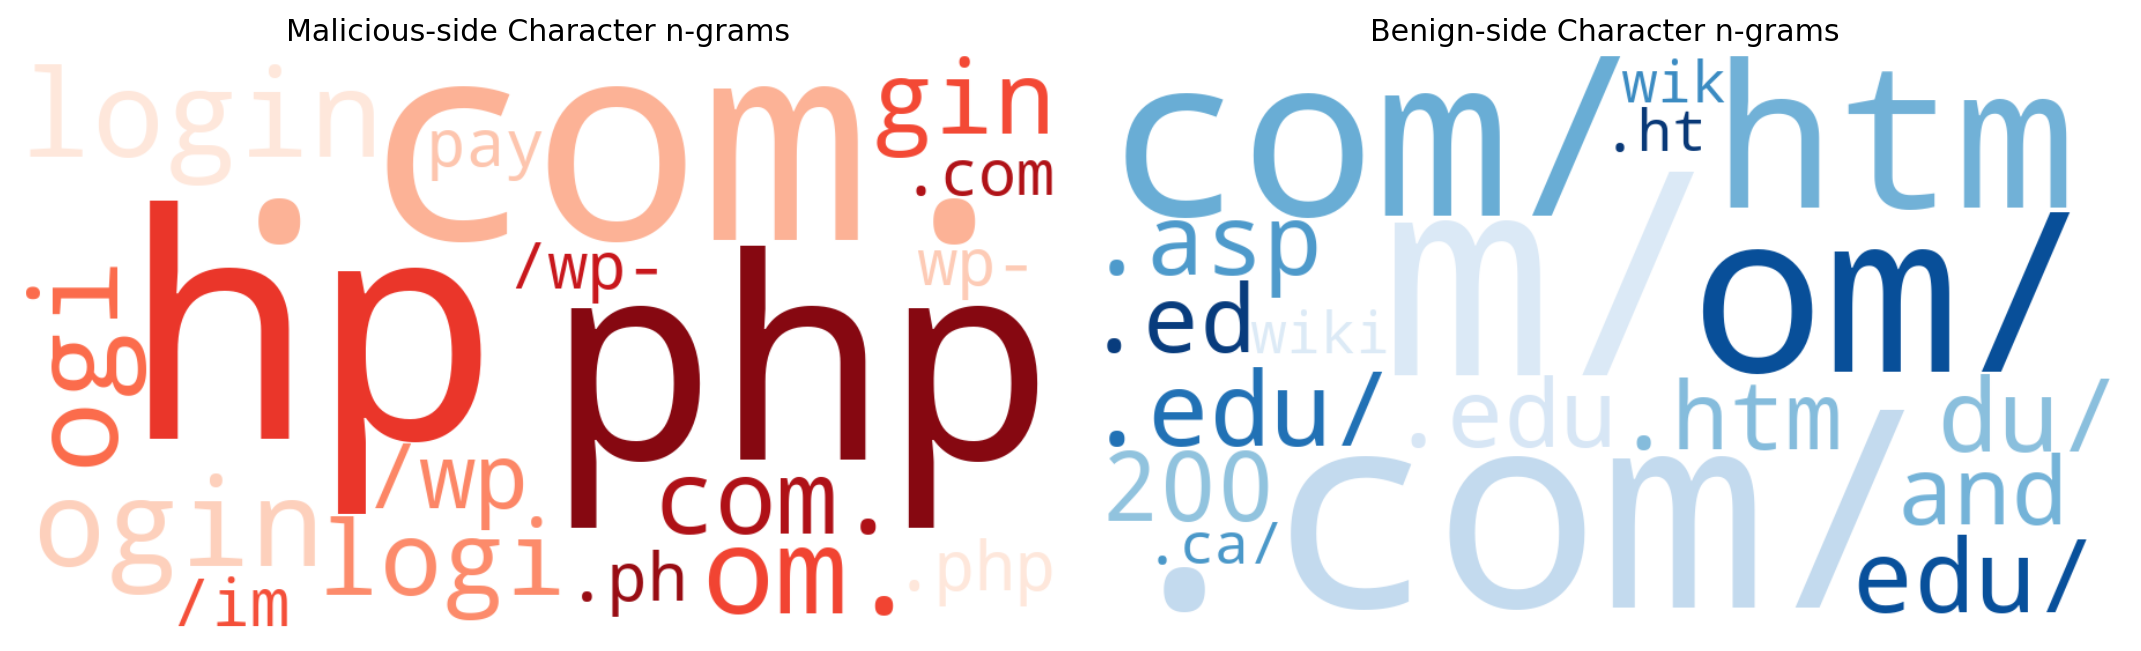

In [13]:
bad_freq = {row["ngram"].strip(): abs(row["weight"]) for row in top_bad if row["ngram"].strip()}
good_freq = {row["ngram"].strip(): abs(row["weight"]) for row in top_good if row["ngram"].strip()}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bad_wc = WordCloud(width=900, height=500, background_color="white", colormap="Reds")
bad_wc.generate_from_frequencies(bad_freq)
axes[0].imshow(bad_wc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Malicious-side Character n-grams")

good_wc = WordCloud(width=900, height=500, background_color="white", colormap="Blues")
good_wc.generate_from_frequencies(good_freq)
axes[1].imshow(good_wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Benign-side Character n-grams")

figure_path = save_figure("ngram-wordclouds.png")
display(Image(filename=str(figure_path)))
plt.close(fig)

### 图表解读：词云图

- 如果你只想在正文保留一张图，请优先用上面的条形图，不要用词云。
- 词云的作用更像“展示模型关注片段的大致风格”，不是严格比较。
- 对字符级模型来说，词云更容易受 `.php`、`login`、`com/` 这种高频碎片影响，所以应配合条形图一起看。

## 5. 为什么当前仓库保留这套方案

**好处**

1. 特征和模型都很轻量，后端加载与推理成本低。
2. 对 URL 这种短文本，字符级特征通常比词级特征更稳。
3. `LogisticRegression` 比 `SGDClassifier` 更稳定，概率输出也更顺。
4. 和 VT URL reputation 结合时，URL 模型主要承担“结构风险补充”，不需要一个很重的模型。

**代价**

1. 解释性弱于规则系统。
2. 对新型短链、重定向链、上下文语义无能为力。
3. 单独使用时仍可能出现误报，因此主系统会结合 VT、内容复核和附件沙箱。

**本 notebook 生成的图表文件**

- `dataset-label-distribution.png`
- `model-metric-comparison.png`
- `roc-curves.png`
- `best-model-confusion-matrix.png`
- `feature-weight-bar-charts.png`
- `ngram-wordclouds.png`

它们都会写到 `output/jupyter-notebook/url-model-figures/`，方便直接复制到论文或汇报。

## 6. Exercise

把下面单元里的 `ngram_range` 改成 `(2, 4)`，或者把 `analyzer` 改成 `char` / `word`，重新运行对比指标。

问题：

1. 指标有明显变化吗？
2. ROC 曲线和混淆矩阵是否有结构性变化？
3. 对当前系统来说，这个变化值得上线吗？

### Cell Guide 14: 留给你做参数实验

**目的**

- 作为实验记录区，方便你修改 `ngram_range`、`analyzer` 或抽样规模后记录观察。

**执行后你应该看到**

- 这一格默认不运行实际训练，只作为笔记 scaffold

**怎么解读**

如果你要写论文里的消融实验，这一格就是记录结论和对比观察的地方。

In [14]:
# Answer scaffold
# TODO: 修改 build_models() 里的 shared_vectorizer 参数后，重新运行第 3 节和第 4 节。
# 可在这里记录新的 precision / recall / f1 / auc，以及你对词云与混淆矩阵的观察。

## 7. Extensions

如果你想继续深入：

1. 把 host/path/query 拆开，加入词法特征做 hybrid 对比。
2. 单独统计 FPR，在更严格的误报约束下重新排模型。
3. 用自己的真实 benign URL 样本替换公开数据里的正常样本，再看结论是否稳定。